# Robotics, Vision & Control 3e: for Python
## Chapter 6: Localization and Mapping

Copyright (c) 2021- Peter Corke

In [1]:
try:
    import google.colab
    print('Running on CoLab')
    COLAB = True
    #!pip install roboticstoolbox-python>=1.0.2
    !pip install git+https://github.com/petercorke/robotics-toolbox-python@future
    !pip install spatialmath-python>=1.1.5
    !pip install --no-deps rvc3python
except ModuleNotFoundError:
    COLAB = False

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "last_expr_or_assign"
from IPython.display import HTML

import matplotlib.pyplot as plt

# add RTB examples folder to the path
import sys, os.path
import RVC3 as rvc
sys.path.append(os.path.join(rvc.__path__[0], 'models'))

# ------ standard imports ------ #
%matplotlib widget 
import numpy as np
import math
from math import pi 
np.set_printoptions(
    linewidth=120, formatter={
        'float': lambda x: f"{0:8.4g}" if abs(x) < 1e-10 else f"{x:8.4g}"})
np.random.seed(0)
from spatialmath import *
from spatialmath.base import *
from roboticstoolbox import *

There are some minor code changes compared to the book. These are to support 
animations in the Jupyter environment. Animations can be made using `FuncAnimation` and
the `widget` backend, but with Colab these can be very unsmooth.  Instead we render the 
animations to HTML5 and render them locally in the browser.

# 6.1 Dead Reckoning using Odometry


## 6.1.1 Modeling the Robot


In [2]:
V = np.diag([0.02, np.deg2rad(0.5)]) ** 2; # simulamos el ruido de sensores de odometria con una matriz de convarianza 
V

array([[  0.0004,        0],
       [       0, 7.615e-05]])

In [3]:
robot = Bicycle(covar=V, animation="car")


Bicycle: x = [ 0, 0, 0 ]
  L=1, steer_max=1.41372, speed_max=inf, accel_max=inf

In [4]:
odo = robot.step((1, 0.3)) # simulamos un paso con v lineal 1 y angulo de dirección 0.3 rad, esto entrega una odometría estimada al hacer el mov. 

array([  0.1025,  0.02978])

In [5]:
robot.q # representa posicion y orientación, coordenadas (x,y) y orientación  ern radianes 

array([     0.1,        0,  0.03093])

In [6]:
robot.f([0, 0, 0], odo)  # Aplica la función de traslación para predecir la nueva pose del robot desde [0,0,0] usando la odometría ya estimada. 

array([  0.1025,        0,  0.02978])

In [7]:
robot.control = RandomPath(workspace=10) # Se configura un controlador de movimiento aleatorio dentro de un espacio de trabajo de 10 unidades.

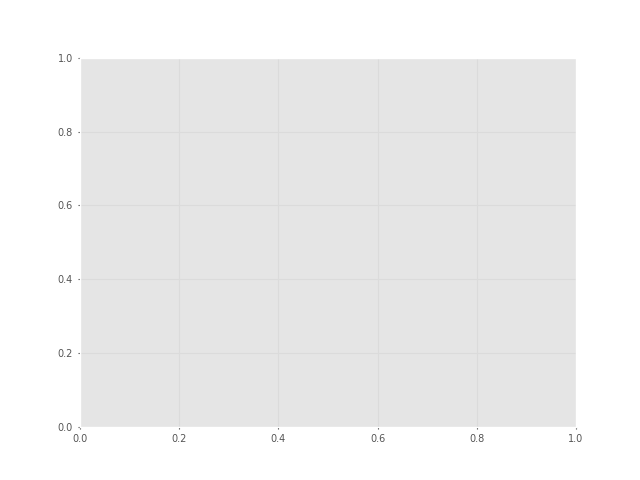

In [8]:
robot.run_animation(T=30) # Ejecuta la animación del robot durante 30 segundos, mostrando su movimiento basado en el controlador aleatorio configurado.

## 6.1.2 Estimating Pose


In [9]:
robot.Fx([0, 0, 0], [0.5, 0.1])   # se calcula el jacobiano de la función de movimiento del robot,
# es decir, la derivada de la función de movimiento respecto a la posición y orientación actual del 

array([[       1,        0,        0],
       [       0,        1,      0.5],
       [       0,        0,        1]])

In [10]:
x_sdev = [0.05, 0.05, np.deg2rad(0.5)];# covaraianza inicial para el estado del robot
x_sdev

[0.05, 0.05, 0.008726646259971648]

In [11]:
P0 = np.diag(x_sdev) ** 2; # matriz diagonal inicial del filtro de Kalman 
P0 

array([[  0.0025,        0,        0],
       [       0,   0.0025,        0],
       [       0,        0, 7.615e-05]])

In [12]:
# now create a extender version of kalman filter
ekf = EKF(robot=(robot, V), P0=P0)

EKF object: 3 states, estimating: vehicle pose, map
  robot: Bicycle: x = [ 0, 0, 0 ]
    L=1, steer_max=1.41372, speed_max=inf, accel_max=inf
  V_est:  [ 0.0004, 0 | 0, 7.62e-05 ]

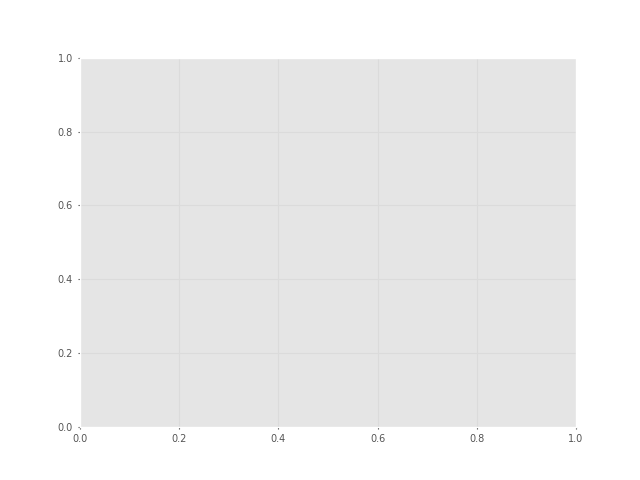

In [13]:
        
ekf.run_animation(T=30) 

In [14]:
t = ekf.get_t(); # tiempos de cada paso 
pn = ekf.get_Pnorm(); # norma de la matriz de cov (medida general de incertidumbre)
plt.plot(t, pn); # filtro con 

In [15]:
pn 

array([3.323e-05, 4.343e-05, 5.314e-05, 6.263e-05, 7.203e-05, 8.143e-05, 9.085e-05, 0.0001004, 0.0001101,  0.00012,
       0.0001303, 0.0001409, 0.0001519, 0.0001634, 0.0001752, 0.0001875, 0.0002004, 0.0002138, 0.0002278, 0.0002425,
       0.0002577, 0.0002738, 0.0002906, 0.0003082, 0.0003267, 0.0003461, 0.000366, 0.0003864, 0.0004076, 0.0004293,
       0.0004515, 0.0004745, 0.0004983, 0.0005228, 0.0005482, 0.0005741, 0.0006009, 0.0006285, 0.0006567, 0.0006856,
       0.0007153, 0.0007455, 0.0007761, 0.0008075, 0.0008395, 0.000872, 0.0009051, 0.0009388, 0.0009732, 0.001008,
       0.001043, 0.001079, 0.001116, 0.001154, 0.001191, 0.001229, 0.001268, 0.001308, 0.001348,  0.00139, 0.001432,
       0.001475, 0.001518, 0.001563, 0.001607, 0.001652, 0.001698, 0.001745, 0.001793, 0.001841,  0.00189, 0.001939,
       0.001989,  0.00204, 0.002091, 0.002143, 0.002195, 0.002248, 0.002302, 0.002357, 0.002412, 0.002468, 0.002526,
       0.002585, 0.002645, 0.002706, 0.002769, 0.002833, 0.002897, 0

In [16]:
robot.plot_xy(color="b") #  trayectoria real 
ekf.plot_xy(color="r") # estimada usando Kalman 

In [17]:
ekf.plot_xy(color="r")
ekf.plot_ellipse(filled=True, facecolor="g", alpha=0.3)

In [18]:
P150 = ekf.get_P(150)

array([[  0.1666, -0.04335,  0.03476],
       [-0.04335,  0.09977, -0.01525],
       [ 0.03476, -0.01525,  0.01158]])

In [19]:
np.sqrt(P150[0, 0]) # desviacion estandar de la posición x estimadat
 #  68% de probabilidad de que la posición real en x esté dentro de ±0.41 metros de la estimada

0.4081316906810882

In [20]:
np.sqrt(P150[1, 1]) # desviacion estandar de la posición y

0.3158704661243764

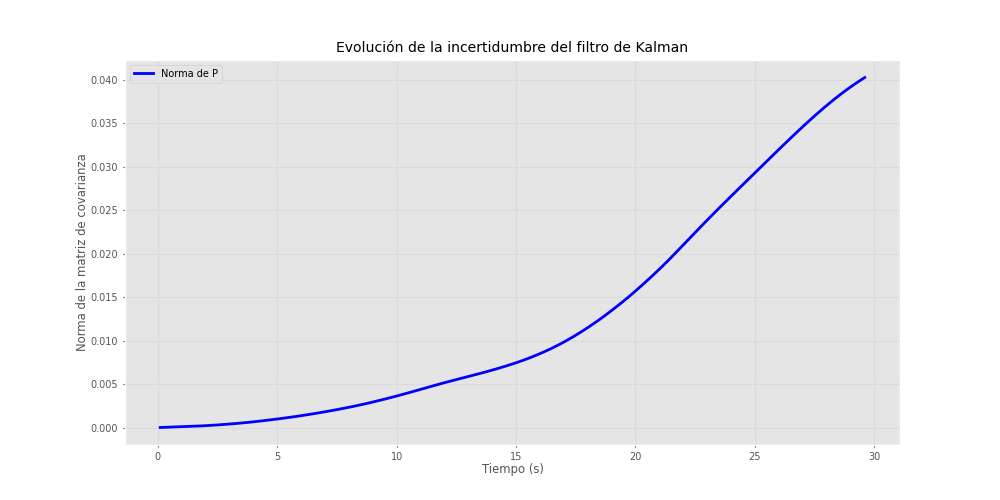

In [21]:
plt.figure(figsize=(10, 5))  

t = ekf.get_t()       
pn = ekf.get_Pnorm() 

plt.plot(t, pn, 'b-', linewidth=2, label='Norma de P')
plt.xlabel('Tiempo (s)')
plt.ylabel('Norma de la matriz de covarianza')
plt.title('Evolución de la incertidumbre del filtro de Kalman')
plt.grid(True)
plt.legend()
plt.show()  

# 6.2 Localizing with a Landmark Map


In [22]:
map = LandmarkMap(20, workspace=10)

LandmarkMap object with 20 landmarks, workspace=(-10.0: 10.0, -10.0: 10.0)

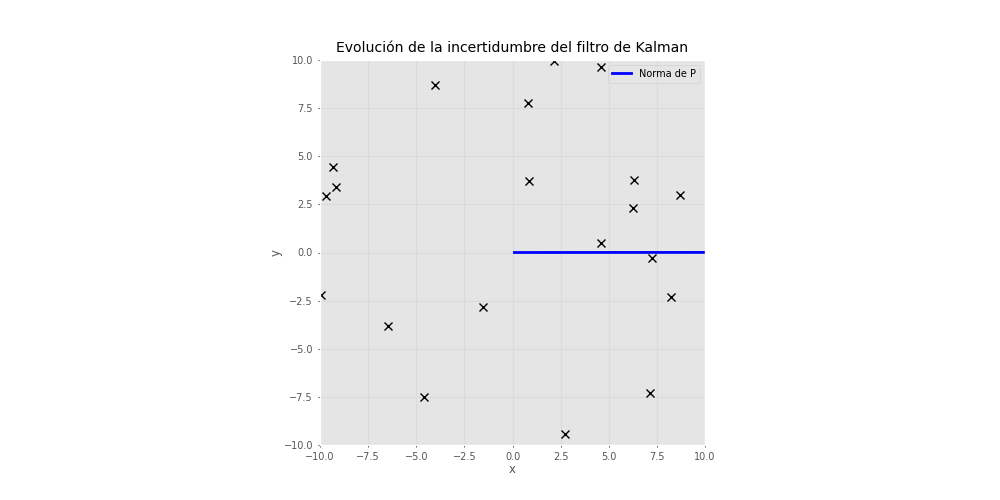

In [23]:

map.plot() # plot he landmark map 
plt.show()


In [24]:
W = np.diag([0.1, np.deg2rad(1)]) ** 2;
W

array([[    0.01,        0],
       [       0, 0.0003046]])

In [25]:
sensor = RangeBearingSensor(robot=robot, map=map, covar=W,   
           angle=[-pi/2, pi/2], range=4 ) #define a range-bearing sensor with a covariance matrix W, covering angles from -90 to 90 degrees and a maximum range of 4 units.



RangeBearingSensor sensor class
  LandmarkMap object with 20 landmarks, workspace=(-10.0: 10.0, -10.0: 10.0)
  W = [ 0.01, 0 | 0, 0.000305 ]
  sampled every 1 samples
  range: (0: 4)
  angle: (-1.57: 1.57)

In [26]:
robot.control = RandomPath(workspace=map, seed=3)


In [27]:
ekf = EKF(robot=(robot, V), P0=P0, map=map, sensor=(sensor, W));

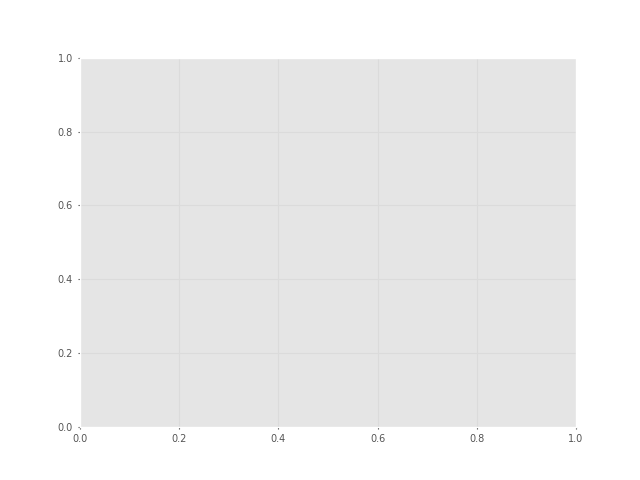

In [28]:
ekf.run_animation(T=30)

In [29]:
z, i = sensor.reading() # usefull to kalman filter 
# z
# i
print(f"landmark {i} at {z}")

landmark None at None


In [30]:
map[17] ## see the reference position 

array([  0.8292,     7.79])

In [31]:
map.plot()
robot.plot_xy();
ekf.plot_xy();
ekf.plot_ellipse()

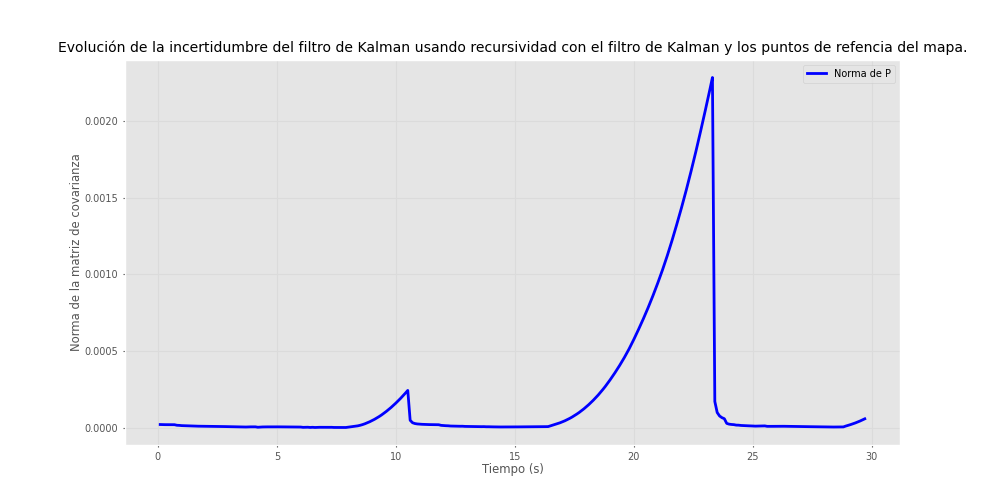

In [32]:
plt.figure(figsize=(10, 5))  

t = ekf.get_t()       
pn = ekf.get_Pnorm() 

plt.plot(t, pn, 'b-', linewidth=2, label='Norma de P')
plt.xlabel('Tiempo (s)')
plt.ylabel('Norma de la matriz de covarianza')
plt.title('Evolución de la incertidumbre del filtro de Kalman usando recursividad con el filtro de Kalman y los puntos de refencia del mapa.')
plt.grid(True)
plt.legend()
plt.show()  

# 6.3 Creating a Landmark Map


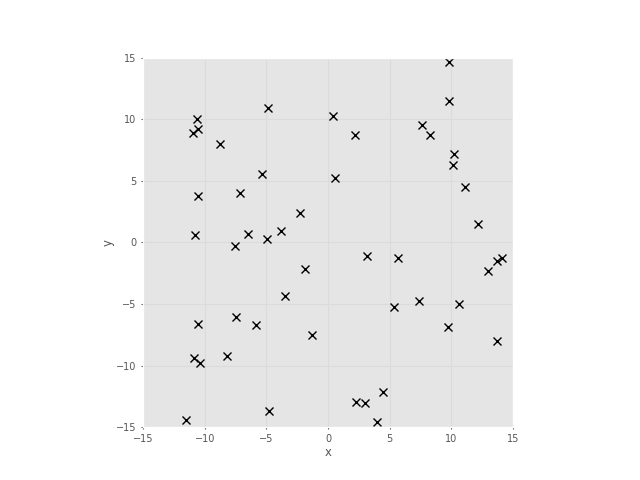

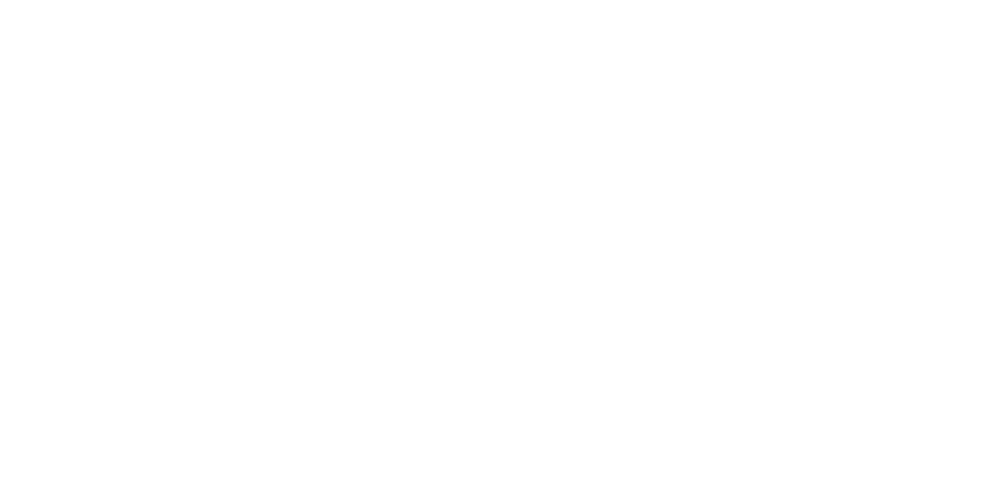

In [33]:
plt.figure(figsize=(10, 5))  

map = LandmarkMap(50, workspace=15, seed=10); # # create a map with 50 landmarks in a 15x15 workspace
map.plot() # plot the landmark map
plt.show()

In [34]:
robot = Bicycle(covar=V, animation="car"); #    # create a robot with a covariance matrix V and a car-like animation


In [35]:
robot.control = RandomPath(workspace=map, seed = 7); #  # set the robot's control to a random path within the map workspace with a seed for reproducibility


In [36]:
W = np.diag([0.1, np.deg2rad(1)]) ** 2 # define the covariance matrix for the sensor, which includes both range and bearing noise
W


array([[    0.01,        0],
       [       0, 0.0003046]])

In [37]:

sensor = RangeBearingSensor(robot=robot, map=map, covar=W, 
           range=4, angle=[-pi/2, pi/2]); # create a range-bearing sensor with the specified covariance matrix, range, and angle limits

In [38]:
print(sensor)

RangeBearingSensor sensor class
  LandmarkMap object with 50 landmarks, workspace=(-15.0: 15.0, -15.0: 15.0)
  W = [ 0.01, 0 | 0, 0.000305 ]
  sampled every 1 samples
  range: (0: 4)
  angle: (-1.57: 1.57)


In [39]:
ekf = EKF(robot=(robot, None), sensor=(sensor, W));  # create an Extended Kalman Filter (EKF) with the robot and sensor, without an initial covariance matrix for the robot

In [40]:
print(ekf)

EKF object: 0 states, estimating: vehicle pose, map
  robot: Bicycle: x = [ 0, 0, 0 ]
    L=1, steer_max=1.41372, speed_max=inf, accel_max=inf
  sensor: RangeBearingSensor sensor class
    LandmarkMap object with 50 landmarks, workspace=(-15.0: 15.0, -15.0: 15.0)
    W = [ 0.01, 0 | 0, 0.000305 ]
    sampled every 1 samples
    range: (0: 4)
    angle: (-1.57: 1.57)
  W_est:  [ 0.01, 0 | 0, 0.000305 ]


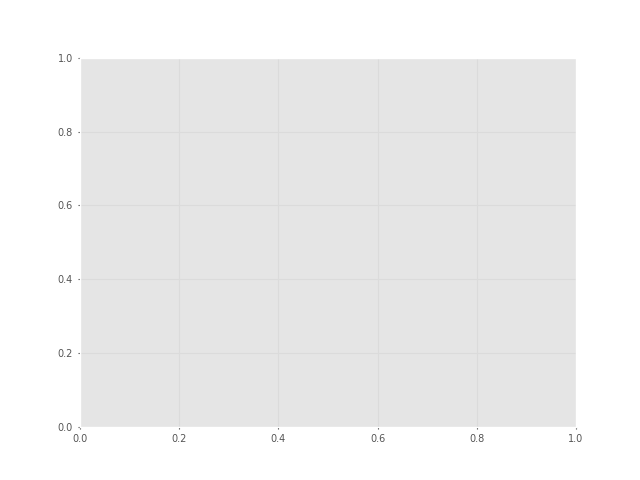

In [41]:
ekf.run_animation(T=50)# run the animation for 50 seconds

In [42]:
map.plot(); # plot the map with landmarks
ekf.plot_map(); # plot the map with landmarks
robot.plot_xy();    # plot real trajectory

In [43]:
i

In [44]:
map[i]

array([[[   13.68,    -8.77,    9.853,   -10.52,   0.3841,   -10.92,    5.671,    10.25,   -2.235,    13.71,
             9.76,   -4.854,    2.273,    7.599,    9.813,       13,   -10.65,    7.367,   -10.82,     12.2,
           -8.217,     10.6,    -5.81,    14.09,    0.535,   -5.326,   -6.527,    3.176,   -4.987,    5.359,
           -10.37,   -7.507,     11.1,    3.011,   -7.141,   -10.52,    -10.9,   -7.532,   -3.515,    4.472,
            10.13,    8.281,   -4.815,   -10.54,   -1.289,   -1.864,    2.227,   -3.802,    4.015,   -11.56]],

       [[  -8.007,    8.017,    14.61,     9.24,    10.29,     8.87,   -1.295,     7.16,    2.354,   -1.478,
           -6.869,    10.94,   -12.94,    9.502,    11.46,   -2.295,    9.997,   -4.769,   0.5937,    1.476,
           -9.214,   -5.003,   -6.674,   -1.273,    5.245,    5.515,   0.7084,   -1.069,   0.2589,   -5.262,
           -9.822,    -6.02,    4.457,   -13.06,    4.011,    -6.63,   -9.421,  -0.3286,   -4.389,   -12.11,
            6.28

In [45]:
ekf.landmark(6) #  see how the landmark 6 is estimated 

(1, 27)

In [46]:
ekf.x_est[24:26] # see the position of the landmark  in the state vector, it is at the end of the state vector

array([   13.03,   -2.283])

In [47]:
ekf.P_est[24:26, 24:26] # print estimate position at this landmarks 

array([[0.0008827, 0.000396],
       [0.000396, 0.001075]])

In [48]:
matriz_covarianza = ekf.P_est[24:26, 24:26]  # acces to the covariance matrix 

print("Matriz SIMÉTRICA de covarianza completa:")
print(matriz_covarianza)



Matriz SIMÉTRICA de covarianza completa:
[[0.0008827 0.000396]
 [0.000396 0.001075]]


# 6.4 Simultaneous Localization and Mapping


In [49]:
map = LandmarkMap(20, workspace=10);
W = np.diag([0.1, np.deg2rad(1)]) ** 2 
robot = Bicycle(covar=V, x0=(3, 6, np.deg2rad(-45)), 
          animation="car");
robot.control = RandomPath(workspace=map);
W = np.diag([0.1, np.deg2rad(1)]) ** 2
sensor = RangeBearingSensor(robot=robot, map=map, covar=W, 
           range=4, angle=[-pi/2, pi/2]);
P0 = np.diag([0.05, 0.05, np.deg2rad(0.5)]) ** 2;
ekf = EKF(robot=(robot, V), P0=P0, sensor=(sensor, W));

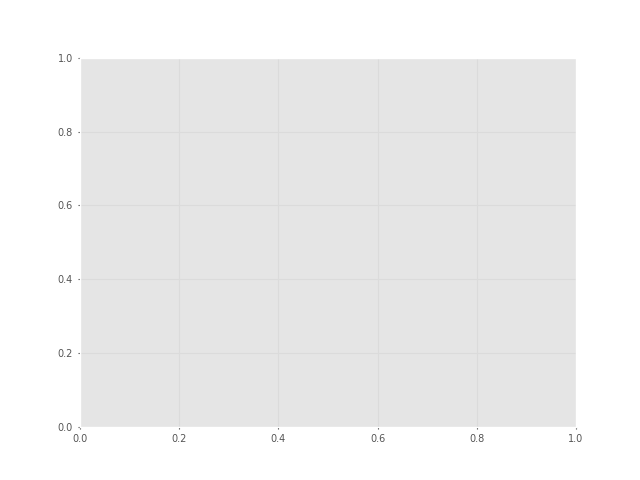

In [50]:
# ekf.run(T=40);
ekf.run_animation(T=40) 

#html = ekf.run_animation(T=40, format="html")
#HTML(html)

In [51]:
map.plot(); # plot true map
robot.plot_xy(); # plot true path

In [52]:
ekf.plot_map();      # plot estimated landmark position
ekf.plot_ellipse();  # plot estimated covariance
ekf.plot_xy();       # plot estimated robot path

In [53]:
T = ekf.get_transform(map)

   0.7085   -0.7057    2.104     
   0.7057    0.7085   -6.316     
   0         0         1         


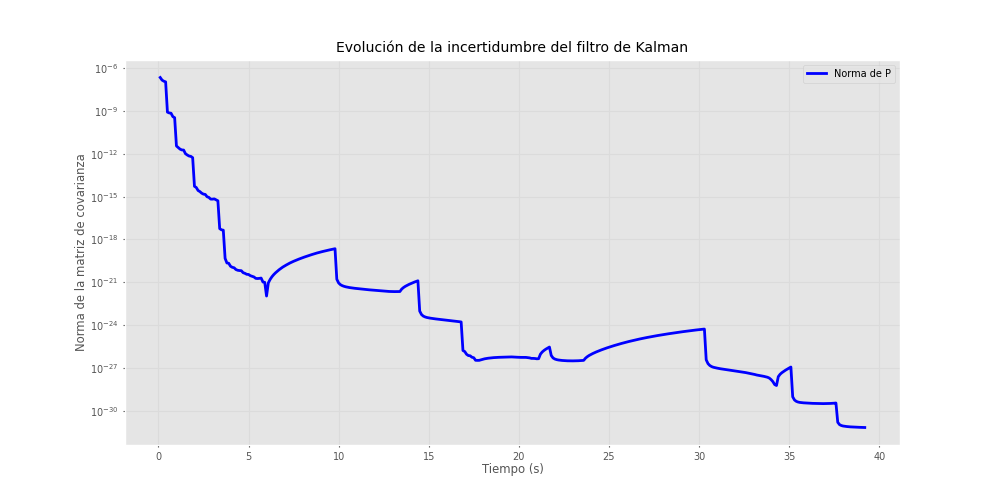

MemoryError: Unable to allocate 374. MiB for an array with shape (3501, 3501, 4) and data type float64

In [54]:
plt.figure(figsize=(10, 5))  

t = ekf.get_t()       
pn = ekf.get_Pnorm() 

plt.plot(t, pn, 'b-', linewidth=2, label='Norma de P')
plt.yscale('log')  # Usamos escala logarítmica en el eje Y

plt.xlabel('Tiempo (s)')
plt.ylabel('Norma de la matriz de covarianza')
plt.title('Evolución de la incertidumbre del filtro de Kalman')
plt.grid(True)
plt.legend()
plt.show()  

# 6.5 Pose-Graph SLAM


NOTE. Minor changes to ensure Jupyter pretty printing of SymPy equations.  Introduced underscore to indicate subscripting, and changed `t` to `theta`
which is printed as $\theta$.

In [ ]:
import sympy
xi, yi, ti, xj, yj, tj = sympy.symbols("x_i y_i theta_i x_j y_j theta_j")
xm, ym, tm = sympy.symbols("x_m y_m theta_m")
xi_e = SE2(xm, ym, tm).inv() * SE2(xi, yi, ti).inv() \
     * SE2(xj, yj, tj);
fk = sympy.Matrix(sympy.simplify(xi_e.xyt()));

In [ ]:
Ai = sympy.simplify(fk.jacobian([xi, yi, ti]))
Ai.shape

In [ ]:
Ai

In [ ]:
pg = PoseGraph("data/pg1.g2o");

In [ ]:
pg.plot();

In [ ]:
# pg.optimize(animate=True)

pg.optimize(animate=False)
pg.plot()

In [ ]:
pg = PoseGraph("data/killian-small.toro");

In [ ]:
pg.plot(text=False)

In [ ]:
pg.optimize()
pg.plot(text=False)

# 6.6 Sequential Monte-Carlo Localization


In [ ]:
map = LandmarkMap(20, workspace=10);

In [ ]:
V = np.diag([0.02, np.deg2rad(0.5)]) ** 2;
robot = Bicycle(covar=V, animation="car", workspace=map);
robot.control = RandomPath(workspace=map)

In [ ]:
W = np.diag([0.1, np.deg2rad(1)]) ** 2;
sensor = RangeBearingSensor(robot, map, covar=W, plot=True);

In [ ]:
R = np.diag([0.1, 0.1, np.deg2rad(1)]) ** 2;

In [ ]:
L = np.diag([0.1, 0.1]);

In [ ]:
pf = ParticleFilter(robot, sensor=sensor, R=R, L=L, nparticles=1000, animate=True);

In [ ]:
# pf.run(T=10);

#html = pf.run_animation(T=10, format="html");
#HTML(html)

In [ ]:
map.plot();
robot.plot_xy();

In [ ]:
pf.plot_xy();

In [ ]:
plt.plot(pf.get_std()[:100,:]);

In [ ]:
pf.plot_pdf()

# 6.8 Application: Lidar


## 6.8.1 Lidar-based Odometry


In [56]:
pg = PoseGraph("data/killian.g2o.zip", lidar=True);

loaded g2o format file: 3873 vertices, 4987 edges
  3873 lidar scans: 180 beams, fov -90.0° to 90.0°, max range 50.0


In [57]:
[r, theta] = pg.scan(100);
r.shape


(180,)

In [58]:
theta.shape

(180,)

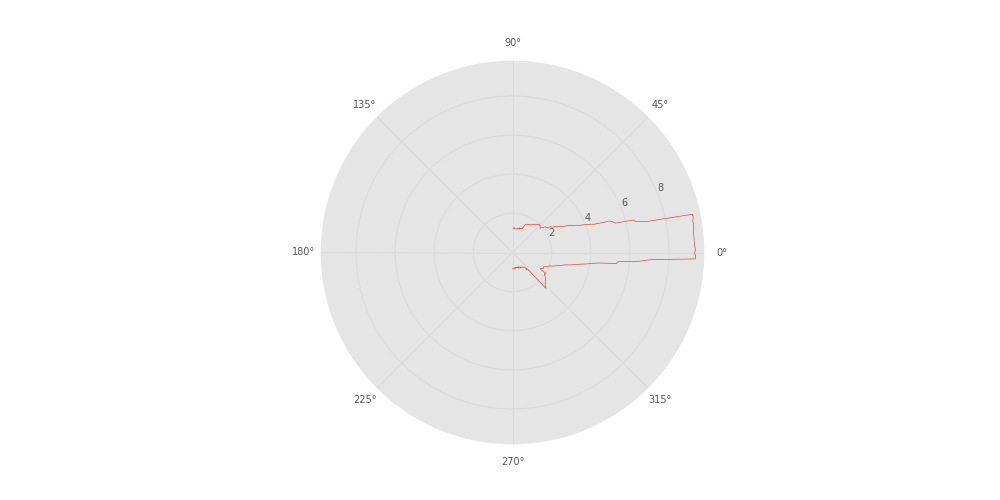

In [59]:

plt.clf()
plt.polar(theta, r);


plt.show()  

In [60]:
p100 = pg.scanxy(100);
p101 = pg.scanxy(100);
p100.shape

(2, 180)

In [61]:
p101.shape

(2, 180)

In [62]:
T = pg.scanmatch(100, 101);
T.printline()

ITER 0 999997.596411268 2.403588732006146
ITER 1 0.7221130437464967 1.6814756882596493
ITER 2 0.3923791519694475 1.2890965362902018
ITER 3 0.6410190269219513 0.6480775093682505
ITER 4 0.18601299152934603 0.46206451783890445
ITER 5 0.061131785319154364 0.4009327325197501
ITER 6 0.05149040620395645 0.34944232631579364
ITER 7 0.042144810439075475 0.30729751587671816
ITER 8 0.033216275089173686 0.2740812407875445
ITER 9 0.10215952758433464 0.17192171320320984
ITER 10 0.005432907099159279 0.16648880610405056
ITER 11 0.005289990692388141 0.16119881541166242
ITER 12 0.002503931709508661 0.15869488370215376
ITER 13 0.002187693034604782 0.16088257673675854
ITER 14 2.6928311810642258e-05 0.1608556484249479
t = 0.506, -0.00872; 2.93°


In [60]:
pg.time(101) - pg.time(100)

1.7599999904632568

In [64]:
# Obtención de los escaneos de LIDAR
r100, theta100 = pg.scan(100)  # Escaneo en la ubicación 100
r101, theta101 = pg.scan(101)  # Escaneo en la ubicación 101


## 6.8.2 Lidar-based Map Building


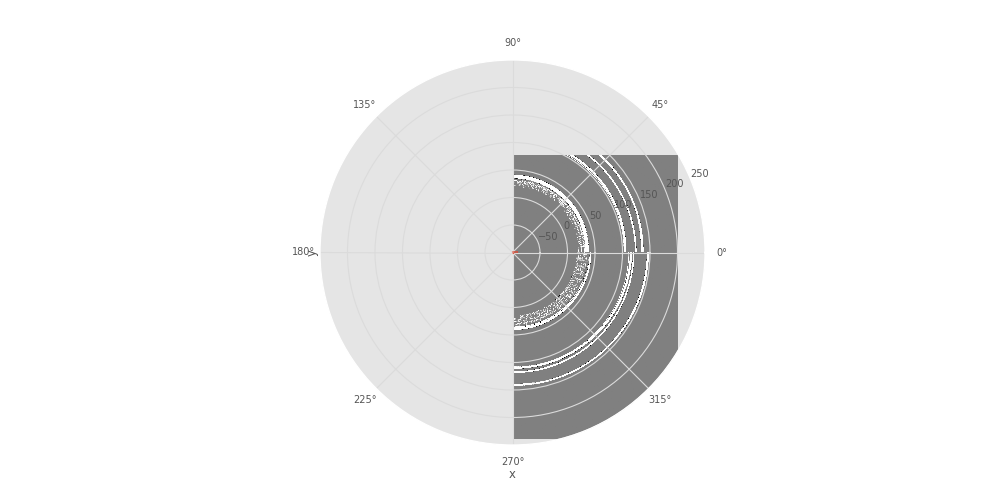

In [67]:
og = OccupancyGrid(workspace=[-100, 250, -100, 250], cellsize=0.1, value=np.int32(0));
pg.scanmap(og, maxrange=40)
og.plot(cmap="gray")
plt.show()